# AML Football Evaluation Notebook (SerieA)

#### This notebook contains evaluation results of SerieA model goals prediction. The aim is to understand what the machine learning model focuses on to make prediction and evaluate it accuracy in doing so.

#### We made sure the same hyperparameters that was used in this evaluation results were used in the production model.

#### evaluation was carried out on the last ten percent of total matches played by each team on the dataset.

#### Training and model achitecture technique on the model will remain private.

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [3]:
seriea = pd.read_csv("Seriea_eval.csv")

In [4]:
seriea.head()

,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,Pred_HomeGoals,Pred_AwayGoals
0,Atalanta,Juventus,0,1,1,1.737588,1.499997
1,Atalanta,Como,1,1,1,2.296113,1.323249
2,Atalanta,Lazio,1,0,0,1.896237,1.147101
3,Atalanta,Cremonese,0,1,1,2.258923,0.691052
4,Atalanta,Milan,1,1,1,1.937190,2.049644


In [5]:
valid = seriea.dropna(subset=["Pred_HomeGoals", "Pred_AwayGoals"])

# Compute MAE
home_mae = mean_absolute_error(valid["GoalsFor"], valid["Pred_HomeGoals"])
away_mae = mean_absolute_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"])

# Compute RMSE
home_rmse = np.sqrt(mean_squared_error(valid["GoalsFor"], valid["Pred_HomeGoals"]))
away_rmse = np.sqrt(mean_squared_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"]))

# Print neatly
print("Model Evaluation Metrics (per match):")
print("-------------------------------------")
print(f"Home Goals -> MAE: {home_mae:.2f}, RMSE: {home_rmse:.2f}")
print(f"Away Goals -> MAE: {away_mae:.2f}, RMSE: {away_rmse:.2f}")
print("\nNotes:")
print("- MAE shows the typical error per match (average goals off).")
print("- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.")

Model Evaluation Metrics (per match):
-------------------------------------
Home Goals -> MAE: 0.86, RMSE: 1.07
Away Goals -> MAE: 0.88, RMSE: 1.11

Notes:
- MAE shows the typical error per match (average goals off).
- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.


In [6]:
seriea.rename(columns={"Pred_HomeGoals": "RawPred_Home"}, inplace=True)
seriea.rename(columns={"Pred_AwayGoals": "RawPred_Away"}, inplace=True)

In [7]:
seriea["Pred_home"] = seriea["RawPred_Home"].round().astype(int)
seriea["Pred_away"] = seriea["RawPred_Away"].round().astype(int)

In [8]:
seriea["Actual_Outcome"] = np.where(seriea["GoalsFor"] > seriea["GoalsAgainst"], "W",
                                    np.where(seriea["GoalsFor"] < seriea["GoalsAgainst"], "L", "D"))

seriea["Predicted_Outcome"] = np.where(seriea["Pred_home"] > seriea["Pred_away"], "W",
                                    np.where(seriea["Pred_home"] < seriea["Pred_away"], "L", "D"))

In [9]:
accuracy = accuracy_score(seriea["Actual_Outcome"], seriea["Predicted_Outcome"])
accuracy

0.4742857142857143

In [10]:
clss_report = classification_report(seriea["Actual_Outcome"].values, seriea["Predicted_Outcome"].values)
print(clss_report)

              precision    recall  f1-score   support

           D       0.31      0.48      0.37       136
           L       0.63      0.50      0.56       209
           W       0.54      0.44      0.48       180

    accuracy                           0.47       525
   macro avg       0.49      0.47      0.47       525
weighted avg       0.52      0.47      0.49       525



In [11]:
seriea["Home_Error"] = seriea["GoalsFor"] - seriea["Pred_home"]
seriea["Away_Error"] = seriea["GoalsAgainst"] - seriea["Pred_away"]

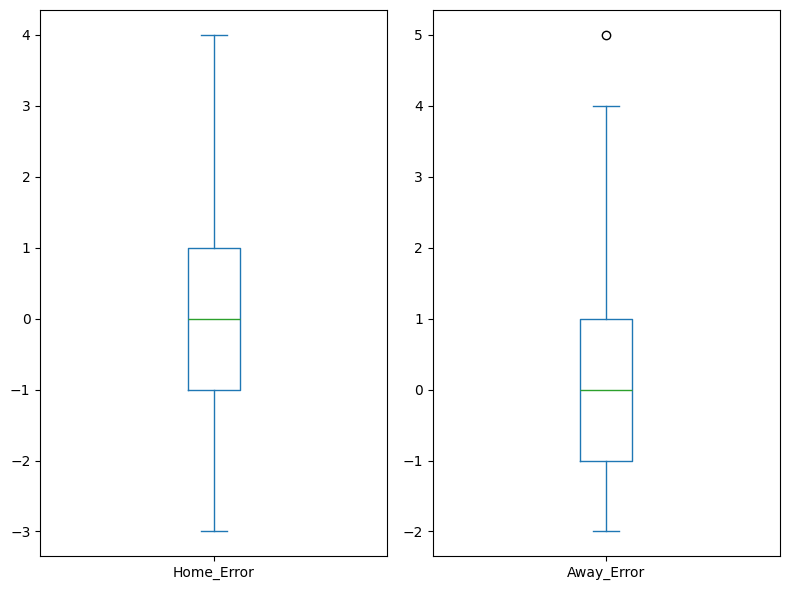

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

seriea["Home_Error"].plot.box(vert=True, ax=axes[0])
seriea["Away_Error"].plot.box(vert=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [13]:
seriea["Home_Error"].value_counts()

Home_Error
-1    173
 0    171
 1    110
 2     35
-2     24
 3      6
 4      4
-3      2
Name: count, dtype: int64

In [14]:
seriea["Away_Error"].value_counts()

Away_Error
 0    172
-1    153
 1    120
 2     40
-2     24
 3     13
 4      2
 5      1
Name: count, dtype: int64

In [15]:
count = seriea["Home_Error"].isin([0, 1, -1]).sum()
print(count/len(seriea))

0.8647619047619047


In [16]:
count = seriea["Away_Error"].isin([0, 1, -1]).sum()
print(count/len(seriea))

0.8476190476190476


In [17]:
seriea["Team"].value_counts()

Team
Atalanta       26
Bologna        26
Fiorentina     26
Inter          26
Juventus       26
Lazio          26
Milan          26
Napoli         26
Roma           26
Torino         26
Udinese        26
Verona         26
Cagliari       22
Genoa          22
Sassuolo       22
Empoli         16
Sampdoria      16
Spezia         16
Lecce          15
Parma          15
Monza          12
Salernitana    12
Benevento       8
Crotone         8
Venezia         8
Como            7
Cremonese       7
Frosinone       4
Pisa            3
Name: count, dtype: int64

In [18]:
def ext_mode(df):
    """
    This code extract the maximum value the model have been wrong by for the team
    """
    maxi = {}

    for team, group in df.groupby("Team"):
        max_value = group["Home_Error"].max()
        maxi[team] = max_value
        
    return maxi

In [19]:
maxi = ext_mode(seriea)

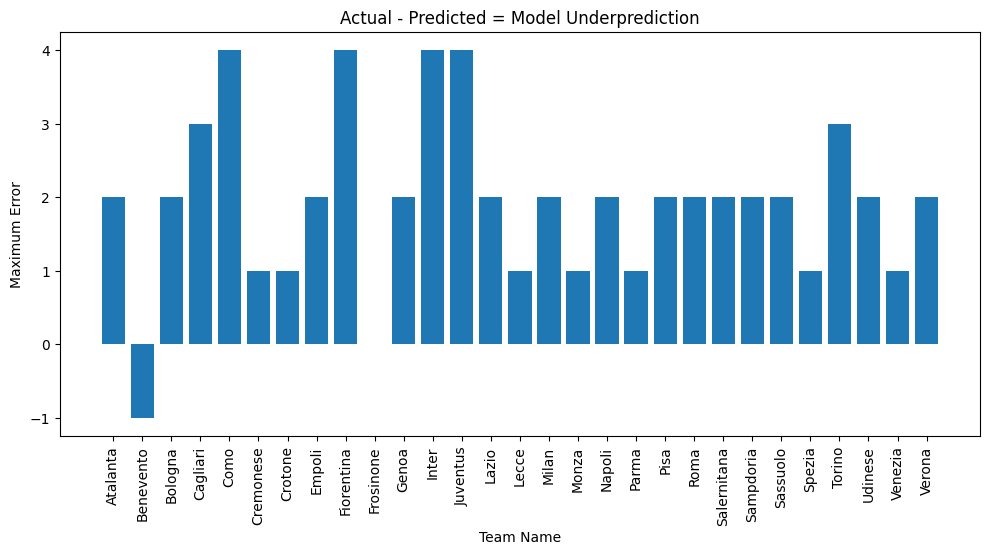

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(maxi.keys(), maxi.values())
plt.xlabel("Team Name")
plt.ylabel("Maximum Error")
plt.title("Actual - Predicted = Model Underprediction")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [24]:
#Checking patterns of teams that performed more than expected have in similar based on the plots above 3, 4 and 5

outliers = seriea[seriea["Home_Error"].isin([3, 4, 5, 6])]
outliers

,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,RawPred_Home,RawPred_Away,Pred_home,Pred_away,Actual_Outcome,Predicted_Outcome,Home_Error,Away_Error
74,Cagliari,Verona,1,4,0,1.239026,1.013641,1,1,W,D,3,-1
88,Como,Pisa,1,5,0,1.358522,0.499742,1,0,W,W,4,0
131,Fiorentina,Udinese,1,5,1,1.343906,1.529238,1,2,W,L,4,-1
144,Fiorentina,Cremonese,0,4,1,0.860486,1.117714,1,1,W,D,3,0
189,Inter,Pisa,1,6,2,2.286812,0.339772,2,0,W,W,4,2
191,Inter,Sassuolo,0,5,0,2.465946,1.058318,2,1,W,W,3,-1
213,Juventus,Cremonese,1,5,0,1.349319,0.712134,1,1,W,D,4,-1
216,Juventus,Parma,0,4,1,1.480682,0.737074,1,1,W,D,3,0
221,Juventus,Pisa,1,4,0,1.023422,0.333699,1,0,W,W,3,0
463,Torino,Parma,1,4,1,0.948750,0.546091,1,1,W,D,3,0


In [23]:
len(outliers)

10

## There is a clear correlation with home team and overscoring what the model predicted. Away team underprediction occured twice in this outlier events with juventus and fiorentina, remaining was home

# SUMMARY

## The model performs badly in 3 way scenerio (i.e home/draw/away) having 47% accuracy which isn't reliable, but performs very good in recognizing possible goals that can be scored, taking into consideration; exact goal, +1, and -1 goals scenerio, with an average accuracy of 86%.

## Outliers events are 3 and 4 goals underprediction. In order to put it out to production, we will focus on managing the risks associated with these errors.